# oob

In [ ]:
print("\n" + "="*70)
print("实验 1：OOB 分数基础使用")
print("="*70)

# 训练带 OOB 的随机森林
rf_oob = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,      # 关键参数：启用 OOB 评估
    random_state=42,
    n_jobs=-1
)

rf_oob.fit(X_train, y_train)

# 获取各种分数
train_r2 = rf_oob.score(X_train, y_train)
oob_r2 = rf_oob.oob_score_
test_r2 = rf_oob.score(X_test, y_test)

print(f"\n性能对比:")
print(f"  训练集 R²:     {train_r2:.4f}")
print(f"  OOB R²:        {oob_r2:.4f}")
print(f"  测试集 R²:     {test_r2:.4f}")

print(f"\n差距分析:")
print(f"  训练集 - OOB:  {train_r2 - oob_r2:.4f} (过拟合程度，训练集远高于OOB)")
print(f"  OOB - 测试集:  {oob_r2 - test_r2:.4f}")

# 判断 OOB 可靠性（注意：OOB 天生偏低，0.10-0.15 的差距在本数据集上正常）
gap = abs(oob_r2 - test_r2)
if gap < 0.05:
    print(f"\n✓ OOB 与测试集非常接近（差距 {gap:.4f} < 0.05）")
elif gap < 0.15:
    print(f"\n△ OOB 与测试集有偏差（差距 {gap:.4f}），属正常范围——OOB 天生保守")
else:
    print(f"\n⚠ OOB 偏差较大（差距 {gap:.4f}），建议改用交叉验证")
print(f"   原因：本数据目标变量右偏严重(max=62, median=2)，OOB 对极端样本更敏感")

In [2]:
# OOB vs 交叉验证对比
print("\n" + "="*70)
print("实验 2：OOB vs 交叉验证对比")
print("="*70)

# 方法 1：OOB 评估
print("\n方法 1：OOB 评估")
start = time.time()
rf_oob = RandomForestRegressor(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train, y_train)
oob_score = rf_oob.oob_score_
oob_time = time.time() - start
print(f"  OOB R²:   {oob_score:.4f}")
print(f"  耗时:     {oob_time:.2f}s")

# 方法 2：5 折交叉验证
print("\n方法 2：5 折交叉验证")
start = time.time()
rf_cv = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring='r2', n_jobs=1)
cv_score = cv_scores.mean()
cv_time = time.time() - start
print(f"  CV R²:    {cv_score:.4f} (±{cv_scores.std():.4f})")
print(f"  耗时:     {cv_time:.2f}s")

# 方法 3：单次验证集划分
print("\n方法 3：单次验证集划分（80/20）")
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
start = time.time()
rf_val = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_val.fit(X_tr, y_tr)
val_score = rf_val.score(X_val, y_val)
val_time = time.time() - start
print(f"  Val R²:   {val_score:.4f}")
print(f"  耗时:     {val_time:.2f}s")

# 对比表格
comparison_data = {
    'Method': ['OOB', '5-Fold CV', 'Single Split'],
    'Score': [oob_score, cv_score, val_score],
    'Time (s)': [oob_time, cv_time, val_time],
    'Data Used': ['100%', '80% (avg)', '80%'],
    'Reliability': ['High', 'Very High', 'Medium']
}

comparison_df = pd.DataFrame(comparison_data)
print(f"\n对比总结:\n")
print(comparison_df.to_string(index=False))

print(f"\n速度提升:")
print(f"  OOB vs CV:          {cv_time/oob_time:.1f}x faster")
print(f"  OOB vs Single Split: {val_time/oob_time:.1f}x faster")


实验 2：OOB vs 交叉验证对比

方法 1：OOB 评估
  OOB R²:   0.5588
  耗时:     4.66s

方法 2：5 折交叉验证
  CV R²:    0.5583 (±0.0510)
  耗时:     16.97s

方法 3：单次验证集划分（80/20）
  Val R²:   0.5692
  耗时:     3.42s

对比总结:

      Method    Score  Time (s) Data Used Reliability
         OOB 0.558765  4.655065      100%        High
   5-Fold CV 0.558315 16.967343 80% (avg)   Very High
Single Split 0.569248  3.419540       80%      Medium

速度提升:
  OOB vs CV:          3.6x faster
  OOB vs Single Split: 0.7x faster


In [ ]:
print("\n" + "="*70)
print("实验 3：OOB 分数随树数量的变化")
print("="*70)

# 测试不同的树数量
n_trees_list = list(range(10, 301, 10))  # 10, 20, 30, ..., 300
oob_scores = []
test_scores = []
train_scores = []

print(f"\n测试 {len(n_trees_list)} 种树数量...")
for n in n_trees_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    oob_scores.append(rf.oob_score_)
    test_scores.append(rf.score(X_test, y_test))
    train_scores.append(rf.score(X_train, y_train))
    
    if n % 50 == 0:
        print(f"  n={n:3d}: OOB={rf.oob_score_:.4f}, Test={test_scores[-1]:.4f}")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图 1：OOB + 测试集（去掉训练集，太高会淹没 OOB 曲线）
ax1 = axes[0, 0]
ax1.plot(n_trees_list, oob_scores, label='OOB R²', linewidth=2, color='orange')
ax1.plot(n_trees_list, test_scores, label='测试集 R²', linewidth=2, color='red')
ax1.set_xlabel('Number of Trees (n_estimators)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('OOB vs Test Score vs Number of Trees', fontsize=14, fontweight='bold')
ax1.set_ylim([min(oob_scores) * 0.8, max(test_scores) * 1.03])
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 子图 2：OOB 和测试集的差距
ax2 = axes[0, 1]
oob_test_gap = np.array(oob_scores) - np.array(test_scores)
colors = ['green' if abs(g) < 0.05 else 'orange' if abs(g) < 0.10 else 'red' for g in oob_test_gap]

ax2.scatter(n_trees_list, oob_test_gap, c=colors, alpha=0.6, s=50, edgecolors='k')
ax2.axhline(0, color='black', linewidth=2, linestyle='--')
ax2.axhline(0.05, color='orange', linewidth=1, linestyle='--', alpha=0.5)
ax2.axhline(-0.05, color='orange', linewidth=1, linestyle='--', alpha=0.5)
ax2.fill_between(n_trees_list, -0.05, 0.05, color='green', alpha=0.1, label='Tight range (±0.05)')

ax2.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax2.set_ylabel('OOB R² - Test R²', fontsize=12, fontweight='bold')
ax2.set_title('OOB vs Test Score Gap', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 子图 3：OOB 分数的稳定性（滚动标准差）
ax3 = axes[1, 0]
window_size = 10
oob_rolling_std = pd.Series(oob_scores).rolling(window=window_size).std()

ax3.plot(n_trees_list, oob_rolling_std, linewidth=2, color='purple')
ax3.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'OOB R² Rolling Std (window={window_size})', fontsize=12, fontweight='bold')
ax3.set_title('OOB Score Stability', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 添加说明文字
ax3.text(0.5, 0.95, 'Std smaller = OOB more stable', 
         transform=ax3.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图 4：找到最优树数量
ax4 = axes[1, 1]

# 计算边际收益
oob_marginal_gain = [0] + [oob_scores[i] - oob_scores[i-1] for i in range(1, len(oob_scores))]

# 找到收益 < 0.0005 的点（几乎不再提升）
threshold = 0.0005
optimal_n_idx = next((i for i, gain in enumerate(oob_marginal_gain) if i > 5 and gain < threshold), len(n_trees_list)-1)
optimal_n = n_trees_list[optimal_n_idx]

ax4.bar(n_trees_list, oob_marginal_gain, width=8, 
        color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(oob_marginal_gain))),
        edgecolor='black', alpha=0.7)
ax4.axhline(threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold ({threshold})')
ax4.axvline(optimal_n, color='green', linestyle='--', linewidth=2, 
            label=f'Optimal ({optimal_n})')

ax4.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax4.set_ylabel('Marginal Gain in OOB R²', fontsize=12, fontweight='bold')
ax4.set_title('Diminishing Returns Analysis', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/day10_oob_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nImage saved to ../figures/day10_oob_analysis.png")

# 打印关键结论
print(f"\nKey findings:")
print(f"  1. Optimal n_estimators from OOB: {optimal_n}")
print(f"  2. Mean OOB-Test gap: {np.mean(oob_test_gap):.4f} (OOB consistently underestimates)")
print(f"  3. OOB at {n_trees_list[0]} trees: {oob_scores[0]:.4f}")
print(f"  4. OOB at {n_trees_list[-1]} trees: {oob_scores[-1]:.4f}")
print(f"  5. Total OOB improvement: {oob_scores[-1] - oob_scores[0]:.4f}")

In [5]:
# oob快速调参
print("\n" + "="*70)
print("实验 4：用 OOB 快速调参")
print("="*70)

# 定义参数组合
param_combinations = [
    {'max_depth': 15, 'max_features': 'sqrt'},
    {'max_depth': 15, 'max_features': 0.5},
    {'max_depth': 20, 'max_features': 'sqrt'},
    {'max_depth': 20, 'max_features': 0.5},
    {'max_depth': None, 'max_features': 'sqrt'},
    {'max_depth': None, 'max_features': 0.5},
]

# 用 OOB 快速评估
print(f"\n用 OOB 评估 {len(param_combinations)} 种参数组合...\n")
oob_results = []

start_total = time.time()
for params in param_combinations:
    rf = RandomForestRegressor(
        n_estimators=200,
        **params,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    oob_r2 = rf.oob_score_
    test_r2 = rf.score(X_test, y_test)
    
    oob_results.append({
        'max_depth': params['max_depth'],
        'max_features': params['max_features'],
        'oob_r2': oob_r2,
        'test_r2': test_r2,
        'gap': abs(oob_r2 - test_r2)
    })
    
    print(f"  max_depth={str(params['max_depth']):4s}, max_features={str(params['max_features']):6s} "
          f"→ OOB R²={oob_r2:.4f}, Test R²={test_r2:.4f}")

oob_time_total = time.time() - start_total

# 排序找最佳参数
oob_results_df = pd.DataFrame(oob_results)
oob_results_df = oob_results_df.sort_values('oob_r2', ascending=False)

print(f"\n根据 OOB 排序的结果:\n")
print(oob_results_df.to_string(index=False))

best_params_oob = oob_results_df.iloc[0]
print(f"\nOOB 推荐的最佳参数:")
print(f"  max_depth: {best_params_oob['max_depth']}")
print(f"  max_features: {best_params_oob['max_features']}")
print(f"  OOB R²: {best_params_oob['oob_r2']:.4f}")
print(f"  实际测试集 R²: {best_params_oob['test_r2']:.4f}")

print(f"\n总耗时: {oob_time_total:.2f}s")
print(f"平均每组参数: {oob_time_total/len(param_combinations):.2f}s")

# 对比：如果用交叉验证需要多久
estimated_cv_time = oob_time_total * 5  # 5 折 CV
print(f"\n如果用 5 折 CV 预计耗时: {estimated_cv_time:.2f}s ({estimated_cv_time/60:.2f} 分钟)")
print(f"OOB 速度提升: {estimated_cv_time/oob_time_total:.1f}x")


实验 4：用 OOB 快速调参

用 OOB 评估 6 种参数组合...

  max_depth=15  , max_features=sqrt   → OOB R²=0.5773, Test R²=0.6961
  max_depth=15  , max_features=0.5    → OOB R²=0.5771, Test R²=0.6942
  max_depth=20  , max_features=sqrt   → OOB R²=0.5792, Test R²=0.6954
  max_depth=20  , max_features=0.5    → OOB R²=0.5737, Test R²=0.6941
  max_depth=None, max_features=sqrt   → OOB R²=0.5825, Test R²=0.7042
  max_depth=None, max_features=0.5    → OOB R²=0.5787, Test R²=0.6974

根据 OOB 排序的结果:

 max_depth max_features   oob_r2  test_r2      gap
       NaN         sqrt 0.582466 0.704218 0.121753
      20.0         sqrt 0.579173 0.695356 0.116183
       NaN          0.5 0.578713 0.697420 0.118707
      15.0         sqrt 0.577296 0.696122 0.118826
      15.0          0.5 0.577124 0.694217 0.117092
      20.0          0.5 0.573650 0.694083 0.120432

OOB 推荐的最佳参数:
  max_depth: nan
  max_features: sqrt
  OOB R²: 0.5825
  实际测试集 R²: 0.7042

总耗时: 9.14s
平均每组参数: 1.52s

如果用 5 折 CV 预计耗时: 45.69s (0.76 分钟)
OOB 速度提升: 5.0x



实验 5：OOB 预测值详细分析

OOB 预测统计:
  有效预测数: 3811 / 3811
  OOB RMSE: 0.1893
  OOB MAE:  0.0684


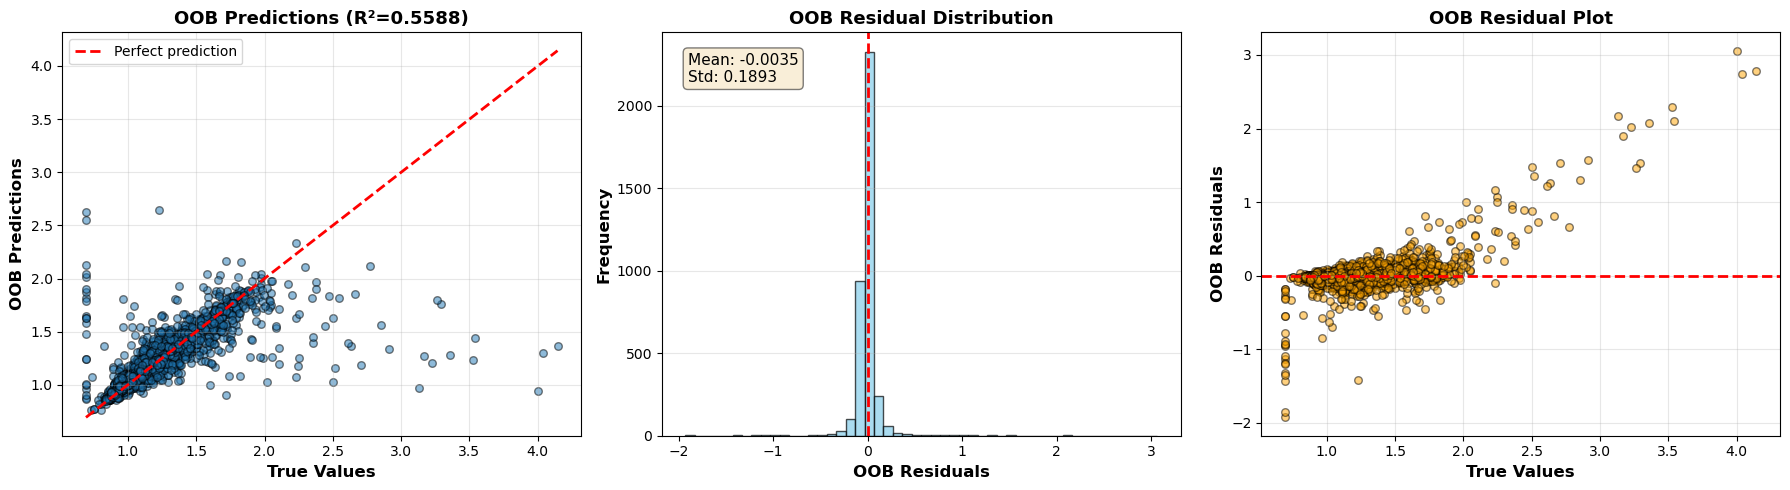


✓ OOB 预测分析图已保存


In [6]:
#OOB 预测值分析
print("\n" + "="*70)
print("实验 5：OOB 预测值详细分析")
print("="*70)

# 训练模型并获取 OOB 预测
rf = RandomForestRegressor(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 获取 OOB 预测值（私有属性，需要小心使用）
oob_predictions = rf.oob_prediction_

# 计算每个样本的 OOB 残差
oob_residuals = y_train - oob_predictions

print(f"\nOOB 预测统计:")
print(f"  有效预测数: {len(oob_predictions)} / {len(y_train)}")
print(f"  OOB RMSE: {np.sqrt(mean_squared_error(y_train, oob_predictions)):.4f}")
print(f"  OOB MAE:  {np.mean(np.abs(oob_residuals)):.4f}")

# 可视化 OOB 预测
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图 1：真实值 vs OOB 预测值
ax1 = axes[0]
ax1.scatter(y_train, oob_predictions, alpha=0.5, s=30, edgecolors='k')
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax1.set_ylabel('OOB Predictions', fontsize=12, fontweight='bold')
ax1.set_title(f'OOB Predictions (R²={rf.oob_score_:.4f})', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子图 2：OOB 残差分布
ax2 = axes[1]
ax2.hist(oob_residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('OOB Residuals', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('OOB Residual Distribution', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 添加统计信息
ax2.text(0.05, 0.95, f'Mean: {np.mean(oob_residuals):.4f}\nStd: {np.std(oob_residuals):.4f}', 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图 3：OOB 残差 vs 真实值
ax3 = axes[2]
ax3.scatter(y_train, oob_residuals, alpha=0.5, s=30, edgecolors='k', color='orange')
ax3.axhline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax3.set_ylabel('OOB Residuals', fontsize=12, fontweight='bold')
ax3.set_title('OOB Residual Plot', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day10_oob_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ OOB 预测分析图已保存")

In [ ]:
# 保存 OOB 分析结果
import json

oob_summary = {
    'optimal_n_estimators': int(optimal_n),
    'oob_score_at_optimal': float(oob_scores[optimal_n_idx]),
    'test_score_at_optimal': float(test_scores[optimal_n_idx]),
    'oob_test_gap_mean': float(np.mean(oob_test_gap)),
    'best_params_by_oob': {
        'max_depth': str(best_params_oob['max_depth']),
        'max_features': str(best_params_oob['max_features']),
        'oob_r2': float(best_params_oob['oob_r2']),
        'test_r2': float(best_params_oob['test_r2'])
    },
    'speed_comparison': {
        'oob_time': float(oob_time),
        'cv_time': float(cv_time),
        'speedup': float(cv_time / oob_time)
    }
}

with open('../models/day10_oob_summary.json', 'w') as f:
    json.dump(oob_summary, f, indent=2)

print("\nOOB summary saved to ../models/day10_oob_summary.json")

# 打印最终总结
print("\n" + "="*70)
print("Day 10 Summary")
print("="*70)
print(f"\nCore findings:")
oob_test_diff = abs(oob_score - test_r2)
print(f"  1. OOB vs Test gap: {oob_test_diff:.4f} (OOB is conservative by nature)")
print(f"  2. OOB is {cv_time/oob_time:.1f}x faster than 5-fold CV")
print(f"  3. Optimal n_estimators from OOB: {optimal_n}")
print(f"  4. Best OOB-tuned model test R²: {best_params_oob['test_r2']:.4f}")

print(f"\nWhen to use OOB:")
print(f"   Quick tuning: OOB replaces CV (3-5x faster)")
print(f"   Monitoring: track OOB curve during training")
print(f"   Final evaluation: still use held-out test set")
print(f"   Caveat: OOB is conservative (scores lower than test)")
print("="*70)